# 05 Fig5 Conformal Landscape

Notebook-first article reproduction. Calculations are kept in notebook cells.

## Fig. 5 and Tables 2-3
Recompute the plain structural model, local conformal intervals, quadrant tables, and the 2x2 confidence landscape from local data.

In [1]:

from pathlib import Path
import json
import math
import pickle
import shutil
import subprocess
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data"
RESULTS = ROOT / "results"
TABLES = RESULTS / "tables"
FIGURES = RESULTS / "figures"
MANUSCRIPT_FIGURES = FIGURES / "manuscript"
MODELS_DIR = RESULTS / "models"
SPLITS_DIR = RESULTS / "splits"
MANUSCRIPT = ROOT / "manuscript"
GENERATED = MANUSCRIPT / "generated"

for path in [TABLES, MANUSCRIPT_FIGURES, MODELS_DIR, SPLITS_DIR, GENERATED]:
    path.mkdir(parents=True, exist_ok=True)

TARGET_COL = "-lgLD50, mol/kg"
CLUSTER_COL = "Butina_clusters"
BBB_FILTER_COL = "bbb_rule_pass"
LIGAND_ID_COL = "ligand_id"
FP_PREFIX = "FP_"
RANDOM_STATE = 42
CONFIDENCE_SPLIT_INDEX = 0

PROTEINS = [
    "1m2z", "1pbq", "1xoq", "2rh1", "2vt4", "2ydo", "2z5x", "3b66", "3kk6", "3ln1",
    "3rze", "4djh", "4ey7", "4iar", "4mqs", "4n6h", "5cxv", "5i71", "5tvn", "5u09",
    "5va1", "6cm4", "6kpf", "6kux", "6lqa", "6pdj", "6x3x", "6y1z", "7f8y", "7kwe",
    "7ljd", "7wc9", "7xnk", "7ym8", "8e9y", "8ef6", "8fhs", "8pjk", "8st0", "8wty",
    "8xvk", "8yn3", "9eo4", "V1A",
]
MODEL_ORDER = ["Baseline", "PCA", "ADME", "Plain", "BBB pass"]

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.colors import LinearSegmentedColormap, to_rgba
from PIL import Image
from IPython.display import display, Image as IPImage

from catboost import CatBoostRegressor
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

CONFIDENCE_DIR = FIGURES / "confidence"
CONFIDENCE_DIR.mkdir(parents=True, exist_ok=True)

ALPHA = 0.10
CALIB_FRAC = 0.20
H_CONFORMAL = 0.90
NEFF_MIN_CONFORMAL = 80
H_MAP = 0.45
H_COVERAGE = 0.75
NEFF_MIN_MAP = 60
DISPLAY_NEFF_MIN = 120
GRID = 80
X_RANGE = (-9, -4)
COV_VMIN = 0.88
COV_VMAX = 0.92

INK = "#16222e"
GRAPHITE = "#5a6b7a"
SUBTLE = "#7d8a97"
GRID_C = "#e6ebf0"
LOW_SUPPORT = "#6f7a83"
SOFT_CONTOUR_LIGHT = "#7f929e"
SOFT_CONTOUR_DARK = "#f1f5f8"
BLUE_GRAPHITE_LIST = [
    (0.00, "#f4f7fa"), (0.18, "#dbe6ee"), (0.38, "#b3cbdd"),
    (0.58, "#7ba3c3"), (0.78, "#3f6f97"), (1.00, "#16313f"),
]
BG_CMAP = LinearSegmentedColormap.from_list("blue_graphite", [c for _, c in BLUE_GRAPHITE_LIST], N=256)
BG_CMAP.set_bad(LOW_SUPPORT)


In [2]:

def load_split_ids(split_index: int, set_name: str) -> np.ndarray:
    registry = pd.read_csv(SPLITS_DIR / "split_indices.csv")
    active = registry.loc[registry["split_index"].eq(split_index) & registry["set"].eq(set_name)]
    if active.empty:
        raise ValueError(f"No rows for split_index={split_index}, set={set_name}")
    return active["ligand_id"].astype(int).to_numpy()


def load_excluded(path: Path) -> set[int]:
    if not path.exists():
        return set()
    ex = pd.read_csv(path)
    if "scope" not in ex.columns:
        return set()
    return set(ex.loc[ex["scope"].eq("all_model_splits"), "ligand_id"].astype(int))


def weighted_quantile(values: np.ndarray, weights: np.ndarray, q: float) -> float:
    order = np.argsort(values)
    v = values[order]
    w = weights[order]
    total = w.sum()
    if total <= 0:
        return float(np.quantile(values, q))
    cdf = np.cumsum(w) / total
    return float(v[min(np.searchsorted(cdf, q, side="left"), len(v) - 1)])


def local_widths(query_features: np.ndarray, calib_features: np.ndarray, calib_residuals: np.ndarray, global_q: float):
    widths = np.full(query_features.shape[0], np.nan)
    neff = np.full(query_features.shape[0], np.nan)
    for i, row in enumerate(query_features):
        dist2 = np.sum((calib_features - row) ** 2, axis=1)
        w = np.exp(-0.5 * dist2 / (H_CONFORMAL * H_CONFORMAL))
        sw = w.sum()
        if sw <= 0:
            q = global_q
            ne = 0.0
        else:
            ne = sw * sw / np.sum(w * w)
            q = global_q if ne < NEFF_MIN_CONFORMAL else weighted_quantile(calib_residuals, w, 1 - ALPHA)
        widths[i] = 2.0 * q
        neff[i] = ne
    return widths, neff


def make_grid(x: np.ndarray, y_axis: np.ndarray):
    valid = np.isfinite(x) & np.isfinite(y_axis)
    x = x[valid]
    y_axis = y_axis[valid]
    sx = x.std()
    sy = y_axis.std()
    xs = np.linspace(np.percentile(x, 0.5), np.percentile(x, 99.5), GRID)
    ys = np.linspace(np.percentile(y_axis, 0.5), np.percentile(y_axis, 99.5), GRID)
    return xs, ys, sx, sy


def nw_mean_var_neff(x, y_axis, target, xs, ys, sx, sy):
    valid = np.isfinite(x) & np.isfinite(y_axis) & np.isfinite(target)
    x = x[valid]
    y_axis = y_axis[valid]
    target = target[valid]
    mean_map = np.full((len(ys), len(xs)), np.nan)
    var_map = np.full_like(mean_map, np.nan)
    neff_map = np.full_like(mean_map, np.nan)
    xz = x / sx
    yz = y_axis / sy
    for j, gy in enumerate(ys):
        dy = gy / sy - yz
        for i, gx in enumerate(xs):
            dx = gx / sx - xz
            w = np.exp(-0.5 * (dx * dx + dy * dy) / (H_MAP * H_MAP))
            sw = w.sum()
            if sw <= 0:
                continue
            neff = sw * sw / np.sum(w * w)
            neff_map[j, i] = neff
            if neff < NEFF_MIN_MAP:
                continue
            m = np.sum(w * target) / sw
            mean_map[j, i] = m
            var_map[j, i] = np.sum(w * (target - m) ** 2) / sw
    return mean_map, var_map, neff_map


def nw_surface(x, y_axis, values, xs, ys, sx, sy, h=H_MAP):
    valid = np.isfinite(x) & np.isfinite(y_axis) & np.isfinite(values)
    x = x[valid]
    y_axis = y_axis[valid]
    values = values[valid]
    out = np.full((len(ys), len(xs)), np.nan)
    xz = x / sx
    yz = y_axis / sy
    for j, gy in enumerate(ys):
        dy = gy / sy - yz
        for i, gx in enumerate(xs):
            dx = gx / sx - xz
            w = np.exp(-0.5 * (dx * dx + dy * dy) / (h * h))
            sw = w.sum()
            if sw <= 0:
                continue
            neff = sw * sw / np.sum(w * w)
            if neff < NEFF_MIN_MAP:
                continue
            out[j, i] = np.sum(w * values) / sw
    return out


In [3]:

df = pd.read_csv(DATA / "df_final.csv")
excluded = load_excluded(DATA / "excluded_molecules.csv")
df = df[~df[LIGAND_ID_COL].astype(int).isin(excluded)].copy()

train_ids = load_split_ids(CONFIDENCE_SPLIT_INDEX, "train")
test_ids = load_split_ids(CONFIDENCE_SPLIT_INDEX, "test")
train_ids = np.array([i for i in train_ids if i not in excluded], dtype=int)
test_ids = np.array([i for i in test_ids if i not in excluded], dtype=int)

rng = np.random.default_rng(RANDOM_STATE)
train_ids_shuffled = train_ids.copy()
rng.shuffle(train_ids_shuffled)
n_cal = int(round(len(train_ids_shuffled) * CALIB_FRAC))
calib_ids = np.sort(train_ids_shuffled[:n_cal])
model_train_ids = np.sort(train_ids_shuffled[n_cal:])

fp_cols = sorted([c for c in df.columns if c.startswith("FP_")], key=lambda x: int(x.split("_")[1]))
plain_cols = fp_cols + ["MW", "logP"]
id_to_idx = pd.Series(np.arange(len(df)), index=df[LIGAND_ID_COL].astype(int)).to_dict()

def rows(ids: np.ndarray) -> np.ndarray:
    return np.array([id_to_idx[int(i)] for i in ids if int(i) in id_to_idx], dtype=int)

idx_train = rows(model_train_ids)
idx_cal = rows(calib_ids)
idx_test = rows(test_ids)
idx_all = np.arange(len(df))

X_train = df.iloc[idx_train][plain_cols].apply(pd.to_numeric, errors="coerce")
med = X_train.median(numeric_only=True).fillna(0.0)
X_train = X_train.fillna(med)
X_cal = df.iloc[idx_cal][plain_cols].apply(pd.to_numeric, errors="coerce").fillna(med)
X_test = df.iloc[idx_test][plain_cols].apply(pd.to_numeric, errors="coerce").fillna(med)
X_all = df.iloc[idx_all][plain_cols].apply(pd.to_numeric, errors="coerce").fillna(med)

y_train = df.iloc[idx_train][TARGET_COL].to_numpy(float)
y_cal = df.iloc[idx_cal][TARGET_COL].to_numpy(float)
y_test = df.iloc[idx_test][TARGET_COL].to_numpy(float)
y_all = df.iloc[idx_all][TARGET_COL].to_numpy(float)

model = CatBoostRegressor(
    loss_function="RMSE",
    iterations=800,
    learning_rate=0.05,
    depth=6,
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False,
    thread_count=-1,
)
model.fit(X_train, y_train)

pred_cal = model.predict(X_cal)
pred_test = model.predict(X_test)
pred_all = model.predict(X_all)
cal_abs_resid = np.abs(y_cal - pred_cal)
q_level = np.ceil((len(cal_abs_resid) + 1) * (1 - ALPHA)) / len(cal_abs_resid)
global_q = float(np.quantile(cal_abs_resid, q_level, method="higher"))

arr = df[PROTEINS].to_numpy(float)
with np.errstate(invalid="ignore"):
    mean_e = np.nanmean(arr, axis=1)
admet_cols = ["hERG", "Respiratory", "Neurotoxicity-DI"]
admet = df[admet_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0).clip(0, 1)
admet_sum = admet.sum(axis=1).to_numpy(float)
burden_features = np.column_stack([mean_e, admet["hERG"], admet["Respiratory"], admet["Neurotoxicity-DI"]])

cal_feat_raw = burden_features[idx_cal]
feat_mu = np.nanmean(cal_feat_raw, axis=0)
feat_sd = np.nanstd(cal_feat_raw, axis=0)
feat_sd[feat_sd == 0] = 1.0
all_feat = (burden_features - feat_mu) / feat_sd
cal_feat = (cal_feat_raw - feat_mu) / feat_sd
test_feat = all_feat[idx_test]

width_all, neff_all = local_widths(all_feat, cal_feat, cal_abs_resid, global_q)
width_test, neff_test = local_widths(test_feat, cal_feat, cal_abs_resid, global_q)
half_width_test = width_test / 2.0
covered = (y_test >= pred_test - half_width_test) & (y_test <= pred_test + half_width_test)

rmse = float(mean_squared_error(y_test, pred_test) ** 0.5)
mae = float(mean_absolute_error(y_test, pred_test))
r2 = float(r2_score(y_test, pred_test))
sp = float(pd.Series(y_test).corr(pd.Series(pred_test), method="spearman"))
print(rmse, mae, r2, sp, len(idx_train), len(idx_cal), len(idx_test))


0.5005746846941459 0.3507004306212779 0.49970264591037095 0.6884733253360956 8096 2024 2530


In [4]:

# Pheno-only and MIE-only local widths for the quadrant table.
def standardise_from_cal(raw: np.ndarray, cal_indices: np.ndarray):
    cal_raw = raw[cal_indices]
    mu = np.nanmean(cal_raw, axis=0)
    sd = np.nanstd(cal_raw, axis=0)
    sd[sd == 0] = 1.0
    return (raw - mu) / sd, (cal_raw - mu) / sd

pheno_raw = admet[["hERG", "Respiratory", "Neurotoxicity-DI"]].to_numpy(float)
pheno_all, pheno_cal = standardise_from_cal(pheno_raw, idx_cal)
width_pheno, _ = local_widths(pheno_all, pheno_cal, cal_abs_resid, global_q)

mie_raw = mean_e.reshape(-1, 1)
mie_all, mie_cal = standardise_from_cal(mie_raw, idx_cal)
width_mie, _ = local_widths(mie_all, mie_cal, cal_abs_resid, global_q)

half_pheno = width_pheno[idx_test] / 2.0
half_mie = width_mie[idx_test] / 2.0
covered_pheno = (y_test >= pred_test - half_pheno) & (y_test <= pred_test + half_pheno)
covered_mie = (y_test >= pred_test - half_mie) & (y_test <= pred_test + half_mie)

print("joint", np.nanmean(width_test), covered.mean())
print("pheno", np.nanmean(width_pheno[idx_test]), covered_pheno.mean())
print("mie", np.nanmean(width_mie[idx_test]), covered_mie.mean())


joint 1.4625435958451252 0.899604743083004
pheno 1.5033236644258765 0.9039525691699605
mie 1.4870105512791727 0.8956521739130435


In [5]:

test_pred = pd.DataFrame({
    "ligand_id": df.iloc[idx_test][LIGAND_ID_COL].astype(int).to_numpy(),
    "true_lgld50": y_test,
    "pred_lgld50_plain": pred_test,
    "abs_residual": np.abs(y_test - pred_test),
    "local_interval_width_90": width_test,
    "local_half_width_90": half_width_test,
    "covered_90": covered.astype(int),
    "local_neff": neff_test,
    "mean_E_44": mean_e[idx_test],
    "hERG": admet.iloc[idx_test]["hERG"].to_numpy(float),
    "Respiratory": admet.iloc[idx_test]["Respiratory"].to_numpy(float),
    "Neurotoxicity-DI": admet.iloc[idx_test]["Neurotoxicity-DI"].to_numpy(float),
    "admet_toxic_burden": admet_sum[idx_test],
})
test_pred.to_csv(TABLES / "conformal_test_predictions.csv", index=False)

all_width = pd.DataFrame({
    "ligand_id": df[LIGAND_ID_COL].astype(int).to_numpy(),
    "mean_E_44": mean_e,
    "admet_toxic_burden": admet_sum,
    "local_interval_width_90": width_all,
    "local_neff": neff_all,
    "pred_lgld50_plain": pred_all,
})
all_width.to_csv(TABLES / "conformal_width_all_molecules.csv", index=False)

summary = {
    "n_model_train": int(len(idx_train)),
    "n_calibration": int(len(idx_cal)),
    "n_test": int(len(idx_test)),
    "alpha": ALPHA,
    "target_coverage": float(1 - ALPHA),
    "plain_test_rmse": rmse,
    "plain_test_mae": mae,
    "plain_test_r2": r2,
    "plain_test_spearman": sp,
    "global_conformal_q": global_q,
    "global_interval_width": float(2 * global_q),
    "local_test_coverage": float(covered.mean()),
    "local_test_mean_width": float(np.nanmean(width_test)),
    "local_test_median_width": float(np.nanmedian(width_test)),
    "local_test_width_p10": float(np.nanpercentile(width_test, 10)),
    "local_test_width_p90": float(np.nanpercentile(width_test, 90)),
    "local_test_mean_neff": float(np.nanmean(neff_test)),
    "h_conformal_4d": H_CONFORMAL,
    "neff_min_conformal": NEFF_MIN_CONFORMAL,
    "h_map_2d": H_MAP,
    "neff_min_map": NEFF_MIN_MAP,
    "display_neff_min": DISPLAY_NEFF_MIN,
    "mie_metric": "mean_E",
}
pd.DataFrame([summary]).to_csv(TABLES / "conformal_mean_burden_summary.csv", index=False)
with open(TABLES / "conformal_run_config.json", "w") as f:
    json.dump(summary | {"plain_cols": plain_cols, "proteins": PROTEINS}, f, indent=2)
print(json.dumps(summary, indent=2))


{
  "n_model_train": 8096,
  "n_calibration": 2024,
  "n_test": 2530,
  "alpha": 0.1,
  "target_coverage": 0.9,
  "plain_test_rmse": 0.5005746846941459,
  "plain_test_mae": 0.3507004306212779,
  "plain_test_r2": 0.49970264591037095,
  "plain_test_spearman": 0.6884733253360956,
  "global_conformal_q": 0.7641244176044584,
  "global_interval_width": 1.5282488352089167,
  "local_test_coverage": 0.899604743083004,
  "local_test_mean_width": 1.4625435958451252,
  "local_test_median_width": 1.5089061602912945,
  "local_test_width_p10": 1.0950570875219707,
  "local_test_width_p90": 1.751203690443968,
  "local_test_mean_neff": 534.543357035175,
  "h_conformal_4d": 0.9,
  "neff_min_conformal": 80,
  "h_map_2d": 0.45,
  "neff_min_map": 60,
  "display_neff_min": 120,
  "mie_metric": "mean_E"
}


In [6]:

btox_median = float(np.median(admet_sum))
mie_strength_median = float(np.median(-mean_e))
mean_e_median = -mie_strength_median

test_mask = np.zeros(len(df), dtype=bool)
test_mask[idx_test] = True
pheno_label = np.where(admet_sum >= btox_median, "Pheno+", "Pheno-")
mie_label = np.where(mean_e <= mean_e_median, "MIE+", "MIE-")

order = [
    ("Pheno+ MIE+", "Pheno+", "MIE+"),
    ("Pheno+ MIE-", "Pheno+", "MIE-"),
    ("Pheno- MIE+", "Pheno-", "MIE+"),
    ("Pheno- MIE-", "Pheno-", "MIE-"),
]
quadrant_rows = []
for group, p, m in order:
    mask = test_mask & (pheno_label == p) & (mie_label == m)
    test_sel = mask[idx_test]
    quadrant_rows.append({
        "Quadrant": group,
        "n": int(mask.sum()),
        "Joint width": float(np.nanmean(width_test[test_sel])),
        "Pheno-only": float(np.nanmean(width_pheno[idx_test][test_sel])),
        "MIE-only": float(np.nanmean(width_mie[idx_test][test_sel])),
        "Coverage": float(covered[test_sel].mean()),
        "Interval_lt_global_n": int((width_test[test_sel] < 2 * global_q).sum()),
        "Interval_lt_global_denom": int(mask.sum()),
    })

quadrants = pd.DataFrame(quadrant_rows)
quadrants.to_csv(TABLES / "conformal_quadrants.csv", index=False)
pd.DataFrame([{"btox_median": btox_median, "mean_E_44_median": mean_e_median}]).to_csv(TABLES / "conformal_quadrant_thresholds.csv", index=False)
print(quadrants.to_string(index=False))


   Quadrant   n  Joint width  Pheno-only  MIE-only  Coverage  Interval_lt_global_n  Interval_lt_global_denom
Pheno+ MIE+ 751     1.209845    1.303313  1.417171  0.909454                   738                       751
Pheno+ MIE- 524     1.423020    1.382162  1.538077  0.898855                   351                       524
Pheno- MIE+ 544     1.590009    1.651526  1.418287  0.898897                   187                       544
Pheno- MIE- 711     1.661061    1.690489  1.575725  0.890295                    57                       711


In [7]:

def contour_point_at_x(cs, target_x: float, preferred_y: float | None = None):
    candidates = []
    fallback = []
    for seg in cs.allsegs[0]:
        if len(seg) == 0:
            continue
        fallback.extend((float(x), float(y)) for x, y in seg)
        for p0, p1 in zip(seg[:-1], seg[1:]):
            x0, y0 = float(p0[0]), float(p0[1])
            x1, y1 = float(p1[0]), float(p1[1])
            if min(x0, x1) <= target_x <= max(x0, x1):
                if abs(x1 - x0) < 1e-12:
                    candidates.append((target_x, (y0 + y1) / 2.0))
                else:
                    frac = (target_x - x0) / (x1 - x0)
                    candidates.append((target_x, y0 + frac * (y1 - y0)))
    if candidates:
        if preferred_y is None:
            return candidates[len(candidates) // 2]
        return min(candidates, key=lambda p: abs(p[1] - preferred_y))
    if fallback:
        if preferred_y is None:
            return min(fallback, key=lambda p: abs(p[0] - target_x))
        return min(fallback, key=lambda p: abs(p[0] - target_x) + 0.2 * abs(p[1] - preferred_y))
    return target_x, 0.0


def draw_soft_contours(ax, zmat, extent, fmt="%.2f"):
    valid = zmat[np.isfinite(zmat)]
    if len(valid) == 0:
        return
    vmin = float(np.nanpercentile(valid, 4))
    vmax = float(np.nanpercentile(valid, 96))
    levels = np.linspace(vmin, vmax, 8)
    split = len(levels) // 2
    low_levels = levels[:split]
    high_levels = levels[split:]
    if len(low_levels):
        cs_low = ax.contour(zmat, extent=extent, origin="lower", levels=low_levels, colors=[to_rgba(SOFT_CONTOUR_LIGHT, 0.72)], linewidths=0.62)
        ax.clabel(cs_low, fmt=fmt, fontsize=7, colors=SOFT_CONTOUR_LIGHT, inline_spacing=3, inline=True)
    if len(high_levels):
        cs_high = ax.contour(zmat, extent=extent, origin="lower", levels=high_levels, colors=[to_rgba(SOFT_CONTOUR_DARK, 0.72)], linewidths=0.62)
        ax.clabel(cs_high, fmt=fmt, fontsize=7, colors=SOFT_CONTOUR_DARK, inline_spacing=3, inline=True)


def draw_mean_contours(ax, zmat, extent, fmt="%.2f"):
    valid = zmat[np.isfinite(zmat)]
    if len(valid) == 0:
        return
    vmin = float(np.nanpercentile(valid, 4))
    vmax = float(np.nanpercentile(valid, 96))
    levels = np.linspace(vmin, vmax, 8)
    manual_targets = {"2.93": (-5.30, 0.55), "3.44": (-7.50, 0.59), "3.79": (-8.00, 1.93)}
    manual_levels = {fmt % float(level): float(level) for level in levels if fmt % float(level) in manual_targets}
    split = len(levels) // 2
    low_levels = levels[:split]
    high_levels = levels[split:]
    def draw_group(level_group, color):
        group = np.array([lvl for lvl in level_group if fmt % float(lvl) not in manual_targets])
        if len(group) == 0:
            return
        cs = ax.contour(zmat, extent=extent, origin="lower", levels=group, colors=[to_rgba(color, 0.72)], linewidths=0.62)
        ax.clabel(cs, fmt=fmt, fontsize=7, colors=color, inline_spacing=3, inline=True)
    draw_group(low_levels, SOFT_CONTOUR_LIGHT)
    draw_group(high_levels, SOFT_CONTOUR_DARK)
    for label_text, target_level in manual_levels.items():
        color = SOFT_CONTOUR_DARK if target_level >= float(high_levels[0]) else SOFT_CONTOUR_LIGHT
        cs_target = ax.contour(zmat, extent=extent, origin="lower", levels=[target_level], colors=[to_rgba(color, 0.72)], linewidths=0.62)
        label_pos = contour_point_at_x(cs_target, manual_targets[label_text][0], manual_targets[label_text][1])
        ax.clabel(cs_target, fmt=fmt, fontsize=7, colors=color, manual=[label_pos], inline_spacing=3, inline=True)


def draw_coverage_contours(ax, zmat_pct, extent):
    valid = zmat_pct[np.isfinite(zmat_pct)]
    if len(valid) == 0:
        return
    vmin_d = float(np.nanmin(valid))
    vmax_d = float(np.nanmax(valid))
    for lvl, style, lw, clr, lbl_alpha in [(89, "dashed", 0.45, "#b0b0b0", 0.60), (90, "solid", 0.80, "#ffffff", 1.00), (91, "dashed", 0.45, "#b0b0b0", 0.60)]:
        if vmin_d < lvl < vmax_d:
            cs = ax.contour(zmat_pct, extent=extent, origin="lower", levels=[lvl], colors=[clr], linewidths=lw, linestyles=style, alpha=lbl_alpha)
            ax.clabel(cs, fmt="%.0f%%", fontsize=6.5, colors=clr, inline_spacing=2, inline=True)


In [8]:

ARROW_COLOR = "#ffffff"
ARROW_SHADOW = "#000000"

def add_panel_label(ax, label: str):
    txt = ax.text(-0.018, 0.985, label, transform=ax.transAxes, color=INK, fontsize=14, fontweight="bold", ha="right", va="top", zorder=12, clip_on=False)
    txt.set_path_effects([pe.Stroke(linewidth=2.2, foreground="white", alpha=0.95), pe.Normal()])
    txt.set_in_layout(False)


def add_explanatory_arrows(ax):
    def arrow(start, end, lw=1.8, alpha=0.80):
        ann = ax.annotate("", xy=end, xytext=start, xycoords="axes fraction", textcoords="axes fraction", arrowprops=dict(arrowstyle="-|>", color=ARROW_COLOR, alpha=alpha, linewidth=lw, mutation_scale=21.0, shrinkA=0, shrinkB=0), zorder=8)
        if ann.arrow_patch is not None:
            ann.arrow_patch.set_path_effects([pe.Stroke(linewidth=lw + 2.0, foreground=ARROW_SHADOW, alpha=0.30), pe.Normal()])
    def label(text, x, y, rotation=0, size=11.25, ha="center", va="center"):
        txt = ax.text(x, y, text, transform=ax.transAxes, color=ARROW_COLOR, fontsize=size, fontweight="normal", rotation=rotation, rotation_mode="anchor", ha=ha, va=va, zorder=9)
        txt.set_path_effects([pe.Stroke(linewidth=0.8, foreground=ARROW_SHADOW), pe.Normal()])
    arrow((0.86, 0.055), (0.055, 0.055))
    label("stronger panel-wide protein-ligand binding", 0.49, 0.100, size=11.5)
    arrow((0.045, 0.16), (0.045, 0.88))
    label("higher predicted organ toxicity", 0.090, 0.52, rotation=90)
    arrow((0.83, 0.18), (0.20, 0.84), lw=1.7, alpha=0.78)
    diag_angle = np.degrees(np.arctan2(0.84 - 0.18, 0.20 - 0.83)) - 180.0
    label("higher in vivo acute toxicity", 0.55, 0.54, rotation=diag_angle, size=11.125)


def add_panel_diagonal_arrow(ax, text: str, label_shift: float = 0.0):
    start = (0.84, 0.16)
    end = (0.18, 0.82)
    angle = np.degrees(np.arctan2(end[1] - start[1], end[0] - start[0])) - 180.0
    direction = np.array([end[0] - start[0], end[1] - start[1]], dtype=float)
    direction = direction / np.linalg.norm(direction)
    label_x = 0.51 + float(label_shift) * float(direction[0])
    label_y = 0.55 + float(label_shift) * float(direction[1])
    ann = ax.annotate("", xy=end, xytext=start, xycoords="axes fraction", textcoords="axes fraction", arrowprops=dict(arrowstyle="-|>", color=ARROW_COLOR, alpha=0.78, linewidth=1.7, mutation_scale=20.0, shrinkA=0, shrinkB=0), zorder=8)
    if ann.arrow_patch is not None:
        ann.arrow_patch.set_path_effects([pe.Stroke(linewidth=3.6, foreground=ARROW_SHADOW, alpha=0.30), pe.Normal()])
    txt = ax.text(label_x, label_y, text, transform=ax.transAxes, color=ARROW_COLOR, fontsize=11.0, fontweight="normal", rotation=angle, rotation_mode="anchor", ha="center", va="center", linespacing=1.08, zorder=9)
    txt.set_path_effects([pe.Stroke(linewidth=0.8, foreground=ARROW_SHADOW), pe.Normal()])


Saved results/figures/confidence/conformal_burden_maps_mean_44.png size=(2284, 2072)


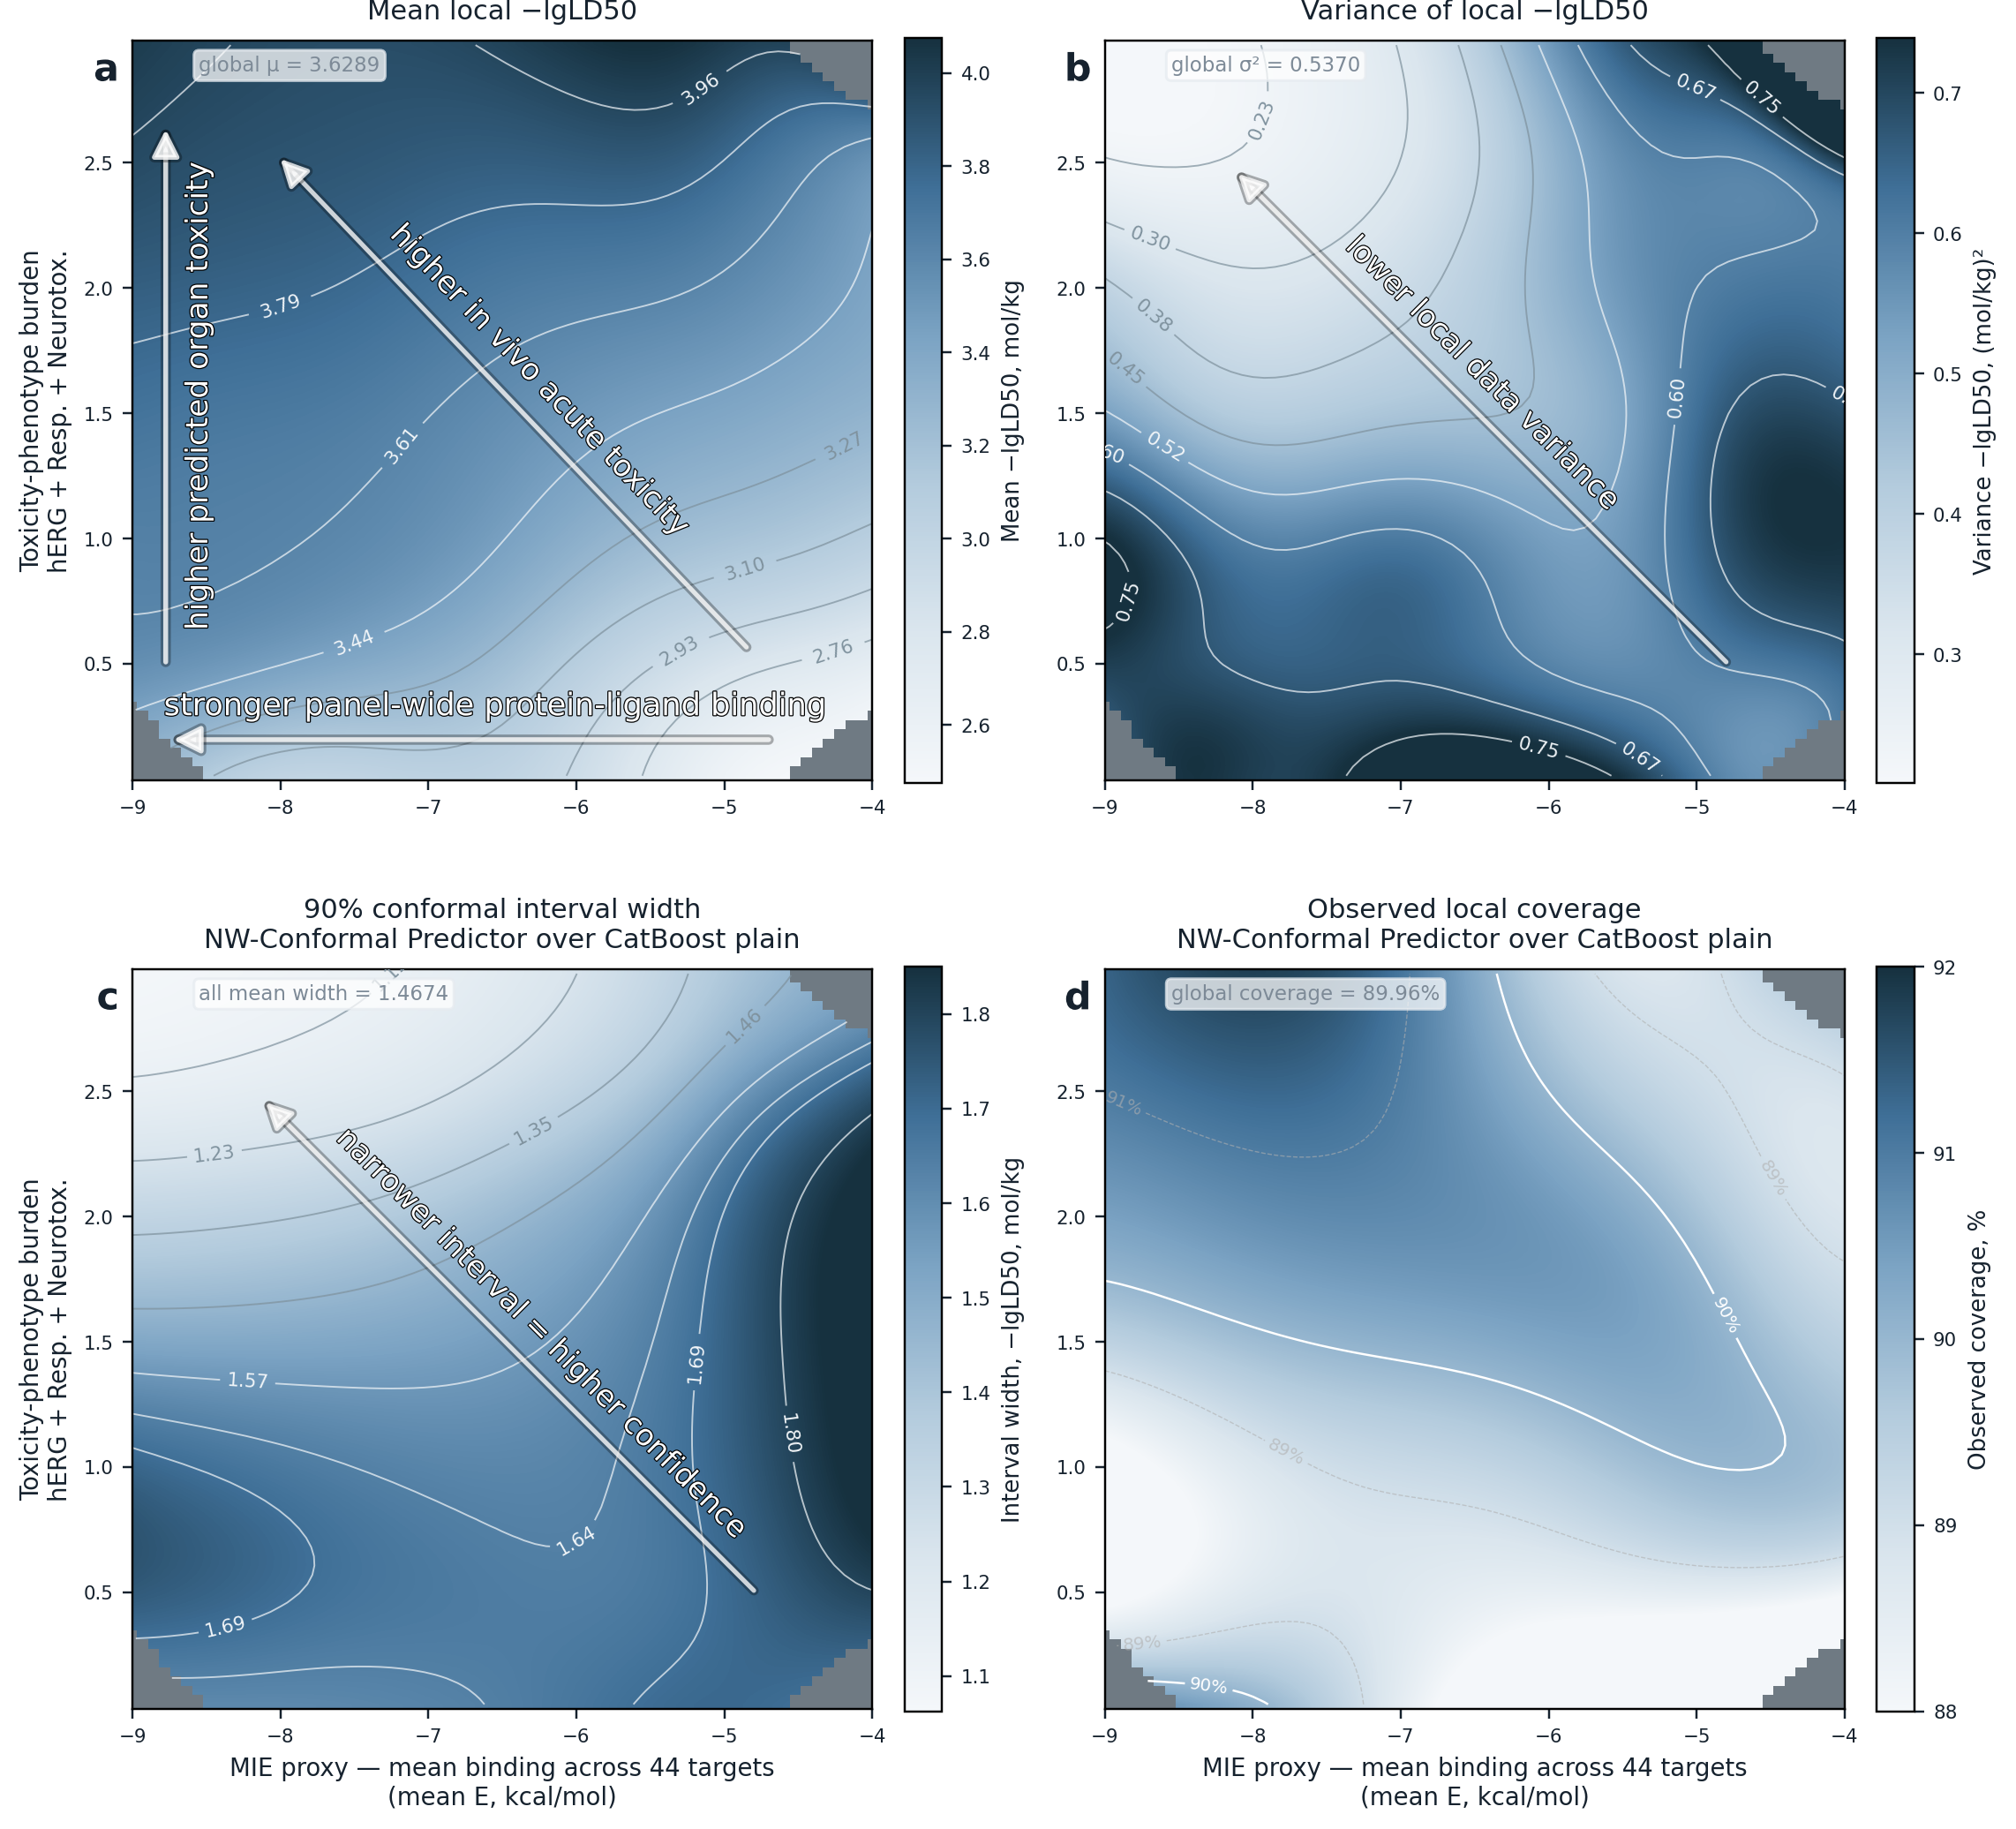

                                                      figure  variance_display_vmin_p2  variance_display_vmax_p95  coverage_h  coverage_display_vmin  coverage_display_vmax  coverage_display_vmin_actual  coverage_display_vmax_actual  global_test_coverage  display_neff_min  x_range  raw_variance_min  raw_variance_max  raw_variance_p95  displayed_grid_fraction layout coverage_colormap  coverage_contour_0.90  coverage_in_percent  suptitle_removed  top_crop_rows
results/figures/confidence/conformal_burden_maps_mean_44.png                   0.20863                   0.738954        0.75                   0.88                   0.92                      0.840109                      0.917862              0.899605               120 (-9, -4)          0.200103          1.793227           0.74607                 0.953281    2x2     blue_graphite                   True                 True              True             23


In [9]:

xs, ys, sx, sy = make_grid(mean_e, admet_sum)
mean_map, var_map, neff_map = nw_mean_var_neff(mean_e, admet_sum, y_all, xs, ys, sx, sy)
width_map = nw_surface(mean_e, admet_sum, width_all, xs, ys, sx, sy, h=H_MAP)

covered_full = np.full(len(df), np.nan)
covered_full[idx_test] = covered.astype(float)
coverage_map = nw_surface(mean_e, admet_sum, covered_full, xs, ys, sx, sy, h=H_COVERAGE)

support_mask = neff_map >= DISPLAY_NEFF_MIN
mean_display = np.where(support_mask, mean_map, np.nan)
var_display = np.where(support_mask, var_map, np.nan)
width_display = np.where(support_mask, width_map, np.nan)
coverage_display = np.where(support_mask, coverage_map, np.nan)
coverage_display_pct = coverage_display * 100.0

var_valid = var_display[np.isfinite(var_display)]
var_vmin = float(np.nanpercentile(var_valid, 2))
var_vmax = float(np.nanpercentile(var_valid, 95))
global_coverage = float(np.nanmean(covered_full))

fig, axes = plt.subplots(2, 2, figsize=(10.5, 10.2), facecolor="white", sharex="all", sharey="all")
extent = [xs[0], xs[-1], ys[0], ys[-1]]
fmt = "%.2f"
panel_defs = [
    (0, 0, mean_display, "Mean local −lgLD50", y_all.mean(), "global μ", None, None, "neither", "Mean −lgLD50, mol/kg"),
    (0, 1, var_display, "Variance of local −lgLD50", y_all.var(), "global σ²", var_vmin, var_vmax, "neither", "Variance −lgLD50, (mol/kg)²"),
    (1, 0, width_display, "90% conformal interval width\nNW-Conformal Predictor over CatBoost plain", float(np.nanmean(width_all)), "all mean width", None, 1.85, "neither", "Interval width, −lgLD50, mol/kg"),
    (1, 1, coverage_display_pct, "Observed local coverage\nNW-Conformal Predictor over CatBoost plain", global_coverage * 100.0, "global coverage", COV_VMIN * 100.0, COV_VMAX * 100.0, "neither", "Observed coverage, %"),
]

for row, col, zmat, title, stat, stat_label, vmin, vmax, extend, cb_label in panel_defs:
    ax = axes[row, col]
    add_panel_label(ax, "abcd"[row * 2 + col])
    zm = np.ma.masked_where(np.isnan(zmat), zmat)
    im = ax.imshow(zm, extent=extent, origin="lower", aspect="auto", cmap=BG_CMAP, interpolation="bilinear", vmin=vmin, vmax=vmax)
    ax.set_box_aspect(1)
    if row == 0 and col == 0:
        draw_mean_contours(ax, zmat, extent, fmt=fmt)
        add_explanatory_arrows(ax)
    elif row == 0 and col == 1:
        draw_soft_contours(ax, zmat, extent, fmt=fmt)
        add_panel_diagonal_arrow(ax, "lower local data variance")
    elif row == 1 and col == 0:
        valid_w = zmat[np.isfinite(zmat)]
        if len(valid_w):
            vmin_c = float(np.nanpercentile(valid_w, 4))
            vmax_c = float(np.nanpercentile(valid_w, 96))
            levels = np.linspace(vmin_c, vmax_c, 8)
            levels[int(np.argmin(np.abs(levels - 1.68)))] = 1.69
            levels[int(np.argmin(np.abs(levels - 1.79)))] = 1.8
            split = len(levels) // 2
            low_levels = levels[:split]
            high_levels = levels[split:]
            if len(low_levels):
                lowest = float(low_levels[0])
                rest_levels = low_levels[1:]
                if len(rest_levels):
                    cs_rest = ax.contour(zmat, extent=extent, origin="lower", levels=rest_levels, colors=[to_rgba(SOFT_CONTOUR_LIGHT, 0.72)], linewidths=0.62)
                    ax.clabel(cs_rest, fmt=fmt, fontsize=7, colors=SOFT_CONTOUR_LIGHT, inline_spacing=3, inline=True)
                cs_lowest = ax.contour(zmat, extent=extent, origin="lower", levels=[lowest], colors=[to_rgba(SOFT_CONTOUR_LIGHT, 0.72)], linewidths=0.62)
                label_pos = contour_point_at_x(cs_lowest, float(extent[0] + 0.50 * (extent[1] - extent[0])), None)
                ax.clabel(cs_lowest, fmt=fmt, fontsize=7, colors=SOFT_CONTOUR_LIGHT, manual=[label_pos], inline_spacing=3, inline=True)
            if len(high_levels):
                cs_high = ax.contour(zmat, extent=extent, origin="lower", levels=high_levels, colors=[to_rgba(SOFT_CONTOUR_DARK, 0.72)], linewidths=0.62)
                ax.clabel(cs_high, fmt=fmt, fontsize=7, colors=SOFT_CONTOUR_DARK, inline_spacing=3, inline=True)
            is_high = 1.64 >= levels[split] if len(levels) > split else True
            cs_164 = ax.contour(zmat, extent=extent, origin="lower", levels=[1.64], colors=[to_rgba(SOFT_CONTOUR_DARK if is_high else SOFT_CONTOUR_LIGHT, 0.72)], linewidths=0.62)
            label_pos = contour_point_at_x(cs_164, -6.0, None)
            ax.clabel(cs_164, fmt=fmt, fontsize=7, colors=SOFT_CONTOUR_DARK if is_high else SOFT_CONTOUR_LIGHT, manual=[label_pos], inline_spacing=3, inline=True)
        add_panel_diagonal_arrow(ax, "narrower interval = higher confidence", label_shift=-0.06)
    elif row == 1 and col == 1:
        draw_coverage_contours(ax, zmat, extent)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, extend=extend)
    if row == 1 and col == 0:
        cbar.set_ticks(np.round(np.arange(1.1, 1.81, 0.1), 1))
    elif row == 1 and col == 1:
        cbar.set_ticks(np.arange(88, 93, 1))
    cbar.set_label(cb_label, fontsize=8.5, color=INK)
    cbar.ax.tick_params(colors=INK, labelsize=7)
    ax.set_xlim(X_RANGE)
    ax.tick_params(colors=INK, labelsize=7)
    ax.set_title(title, fontsize=10, fontweight="normal", pad=8, color=INK)
    stat_display = f"{stat_label} = {stat:.2f}%" if row == 1 and col == 1 else f"{stat_label} = {stat:.4f}"
    ax.text(0.09, 0.98, stat_display, transform=ax.transAxes, fontsize=7.5, color=SUBTLE, va="top", ha="left", zorder=10, bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.75, edgecolor=GRID_C))

for ax in axes[0, :]:
    ax.set_xlabel("")
for ax in axes[1, :]:
    ax.set_xlabel("MIE proxy — mean binding across 44 targets\n(mean E, kcal/mol)", fontsize=9, color=INK)
for ax in axes[:, 1]:
    ax.set_ylabel("")
for ax in axes[:, 0]:
    ax.set_ylabel("Toxicity-phenotype burden\nhERG + Resp. + Neurotox.", fontsize=9, color=INK)
axes[0, 0].tick_params(labelbottom=True)
axes[0, 1].tick_params(labelbottom=True, labelleft=True)
axes[1, 1].tick_params(labelleft=True)

fig.tight_layout(rect=[0, 0, 1, 1])
fig.subplots_adjust(hspace=0.05)
fig_path = CONFIDENCE_DIR / "conformal_burden_maps_mean_44.png"
fig.savefig(fig_path, dpi=220, bbox_inches="tight", facecolor="white")
plt.close(fig)

img = Image.open(fig_path)
arr_img = np.array(img)
content_start = 0
for y in range(arr_img.shape[0]):
    row = arr_img[y, :, :3]
    non_white = np.sum(np.any(row < 240, axis=1))
    if non_white > 50:
        content_start = y
        break
if content_start > 0:
    cropped = img.crop((0, content_start, img.width, arr_img.shape[0]))
    cropped.save(fig_path)

cov_valid = coverage_display[np.isfinite(coverage_display)]
display_stats = pd.DataFrame([{
    "figure": "results/figures/confidence/conformal_burden_maps_mean_44.png",
    "variance_display_vmin_p2": var_vmin,
    "variance_display_vmax_p95": var_vmax,
    "coverage_h": H_COVERAGE,
    "coverage_display_vmin": COV_VMIN,
    "coverage_display_vmax": COV_VMAX,
    "coverage_display_vmin_actual": float(np.nanmin(cov_valid)) if len(cov_valid) else None,
    "coverage_display_vmax_actual": float(np.nanmax(cov_valid)) if len(cov_valid) else None,
    "global_test_coverage": global_coverage,
    "display_neff_min": DISPLAY_NEFF_MIN,
    "x_range": str(X_RANGE),
    "raw_variance_min": float(np.nanmin(var_map)),
    "raw_variance_max": float(np.nanmax(var_map)),
    "raw_variance_p95": float(np.nanpercentile(var_map, 95)),
    "displayed_grid_fraction": float(np.isfinite(var_display).mean()),
    "layout": "2x2",
    "coverage_colormap": "blue_graphite",
    "coverage_contour_0.90": True,
    "coverage_in_percent": True,
    "suptitle_removed": True,
    "top_crop_rows": int(content_start),
}])
display_stats.to_csv(TABLES / "conformal_burden_maps_mean_44.csv", index=False)
shutil.copy2(fig_path, MANUSCRIPT_FIGURES / "fig5.png")
print(f"Saved {fig_path.relative_to(ROOT)} size={Image.open(fig_path).size}")
display(IPImage(filename=str(fig_path)))
print(display_stats.to_string(index=False))
